In [1]:
using Pkg
Pkg.activate("../18337")
using Gridap, Gridap.Geometry, Gridap.Fields, GridapGmsh
using LinearAlgebra

  Activating project at `c:\Rena\MIT2\18.337\18337`


In [2]:
model = GmshDiscreteModel("3D_Bike.msh")
labels = get_face_labeling(model)
println(labels.tag_to_name)

Info    : Reading '3D_Bike.msh'...
Info    : 99 entities
Info    : 11351 nodes
Info    : 66211 elements
Info    : Done reading '3D_Bike.msh'
["NODE_PIN_LEFT_FRONT", "NODE_PIN_LEFT_BACK", "NODE_PIN_UPPER_FRONT", "NODE_PIN_UPPER_BACK", "NODE_LOAD_TOP_LEFT_FRONT", "NODE_LOAD_TOP_LEFT_BACK", "NODE_LOAD_TOP_RIGHT_FRONT", "NODE_LOAD_TOP_RIGHT_BACK", "NODE_LOAD_BOTTOM_FRONT", "NODE_LOAD_BOTTOM_BACK", "PIN_LEFT_PATCH_CURVE_FRONT", "PIN_UPPER_PATCH_CURVE_FRONT", "LOAD_TOP_LEFT_PATCH_CURVE_FRONT", "LOAD_TOP_RIGHT_PATCH_CURVE_FRONT", "LOAD_BOTTOM_PATCH_CURVE_FRONT", "PIN_LEFT_THROUGH_THICKNESS", "PIN_UPPER_THROUGH_THICKNESS", "LOAD_TOP_LEFT_THROUGH_THICKNESS", "LOAD_TOP_RIGHT_THROUGH_THICKNESS", "LOAD_BOTTOM_THROUGH_THICKNESS", "FRONT_FACE", "BACK_FACE", "SIDE_BOUNDARY", "PIN_LEFT_SURFACE", "PIN_UPPER_SURFACE", "LOAD_TOP_LEFT_SURFACE", "LOAD_TOP_RIGHT_SURFACE", "LOAD_BOTTOM_SURFACE", "DESIGN_VOLUME"]


In [3]:
# Define 3D vector-valued FE space
order = 1
reffe = ReferenceFE(lagrangian, VectorValue{3,Float64}, order)

V = TestFESpace(
    model,
    reffe;
    conformity = :H1,
    dirichlet_tags = [
        "PIN_LEFT_SURFACE",
        "PIN_UPPER_SURFACE"
    ],
    dirichlet_masks = [
        (true,  true,  true),   # left pin: fixes ux, uy, uz
        (false, true,  true)    # upper pin/roller: fixes uy, uz, leaves ux free
    ]
)

u_D_left(x)  = VectorValue(0.0, 0.0, 0.0)
u_D_upper(x) = VectorValue(0.0, 0.0, 0.0)

U = TrialFESpace(V, [u_D_left, u_D_upper])
println("Number of displacement DOFs = ", num_free_dofs(V))

Number of displacement DOFs = 33969


In [4]:
# Define integration over volume and boundary load/support surfaces
degree = 2

Ω = Triangulation(model)
dΩ = Measure(Ω, degree)

Ω_d = Triangulation(model, tags = "DESIGN_VOLUME")
dΩ_d = Measure(Ω_d, degree)

Γ_top_left = BoundaryTriangulation(model; tags = "LOAD_TOP_LEFT_SURFACE")
dΓ_top_left = Measure(Γ_top_left, degree)

Γ_top_right = BoundaryTriangulation(model; tags = "LOAD_TOP_RIGHT_SURFACE")
dΓ_top_right = Measure(Γ_top_right, degree)

Γ_bottom = BoundaryTriangulation(model; tags = "LOAD_BOTTOM_SURFACE")
dΓ_bottom = Measure(Γ_bottom, degree)

Γ_pin_left = BoundaryTriangulation(model; tags = "PIN_LEFT_SURFACE")
dΓ_pin_left = Measure(Γ_pin_left, degree)

Γ_pin_upper = BoundaryTriangulation(model; tags = "PIN_UPPER_SURFACE")
dΓ_pin_upper = Measure(Γ_pin_upper, degree)

# -----------------------------
# Immediate geometry sanity checks
# -----------------------------

V_total = sum(∫(1.0)dΩ)
V_design = sum(∫(1.0)dΩ_d)

A_top_left  = sum(∫(1.0)dΓ_top_left)
A_top_right = sum(∫(1.0)dΓ_top_right)
A_bottom    = sum(∫(1.0)dΓ_bottom)

A_pin_left  = sum(∫(1.0)dΓ_pin_left)
A_pin_upper = sum(∫(1.0)dΓ_pin_upper)

println("Total mesh volume      = ", V_total)
println("Design volume          = ", V_design)
println("Top-left load area     = ", A_top_left)
println("Top-right load area    = ", A_top_right)
println("Bottom load area       = ", A_bottom)
println("Left pin surface area  = ", A_pin_left)
println("Upper pin surface area = ", A_pin_upper)
# everything should be positive and nonzero

Total mesh volume      = 0.02717574604188396
Design volume          = 0.02717574604188396
Top-left load area     = 0.004803583458089193
Top-right load area    = 0.004803520790604358
Bottom load area       = 0.002400431027961437
Left pin surface area  = 0.002400000000000001
Upper pin surface area = 0.004800588177598636


In [5]:
# FE spaces for design parameters
p_reffe = ReferenceFE(lagrangian, Float64, 0)
Q = TestFESpace(Ω_d, p_reffe, vector_type = Vector{Float64})
P = Q
np = num_free_dofs(P) # Number of cells in design region (number of design parameters)

pf_reffe = ReferenceFE(lagrangian, Float64, 1)
Qf = TestFESpace(Ω_d, pf_reffe, vector_type = Vector{Float64})
Pf = Qf

UnconstrainedFESpace()

In [6]:
fem_params = (; 
    V, U, Q, P, Qf, Pf, np,
    Ω, dΩ, dΩ_d,
    dΓ_top_left, dΓ_top_right, dΓ_bottom,
    dΓ_pin_left, dΓ_pin_upper
)

println("Number of design variables = ", np)

# -----------------------------
# Immediate design-space sanity check
# -----------------------------

p_uniform = fill(0.30, np)
ph_uniform = FEFunction(P, p_uniform)

raw_volume_residual = sum(∫(ph_uniform - 0.30)dΩ_d)

println("Raw integral of p - Vf over design domain = ", raw_volume_residual)
@assert abs(raw_volume_residual) < 1e-10 * max(1.0, V_design) "Uniform density field is not integrating correctly."

Number of design variables = 56505
Raw integral of p - Vf over design domain = 0.0


In [7]:
# PHYSICAL PARAMETERS — SI units

kgf_to_N = 9.80665

# From the figure:
# E = 700,000 kgf/cm^2
# 1 kgf/cm^2 = 9.80665 / 1e-4 Pa
E0 = 700000.0 * kgf_to_N / 1e-4   # Pa
Emin = 1e-6 * E0                  # ersatz stiffness for void
ν = 0.30
q_simp = 3
Vf = 0.30

# Fig. 9 loads, converted from kgf to N
# Coordinate convention:
# x = horizontal, y = vertical, z = thickness direction

F_top_left  = VectorValue(-10.0 * kgf_to_N, -50.0 * kgf_to_N, 0.0)
F_top_right = VectorValue( 10.0 * kgf_to_N, -10.0 * kgf_to_N, 0.0)
F_bottom    = VectorValue(-15.0 * kgf_to_N, -10.0 * kgf_to_N, 0.0)

phys_params = (; 
    E0, Emin, ν, q_simp, Vf,
    F_top_left, F_top_right, F_bottom
)

# PROBLEM PARAMETERS
r = 0.012       # filter radius R = 1.2 cm = 0.012 m
β = 8.0
η = 0.5

println("E0 [Pa] = ", E0)
println("Emin [Pa] = ", Emin)
println("Vf = ", Vf)
println("Filter radius r [m] = ", r)

println("F_top_left  [N] = ", F_top_left)
println("F_top_right [N] = ", F_top_right)
println("F_bottom    [N] = ", F_bottom)
println("Total applied force [N] = ", F_top_left + F_top_right + F_bottom)

E0 [Pa] = 6.864655e10
Emin [Pa] = 68646.55
Vf = 0.3
Filter radius r [m] = 0.012
F_top_left  [N] = (-98.06649999999999, -490.3325, 0.0)
F_top_right [N] = (98.06649999999999, -98.06649999999999, 0.0)
F_bottom    [N] = (-147.09975, -98.06649999999999, 0.0)
Total applied force [N] = (-147.09975, -686.4655, 0.0)


In [8]:
function ForceVector(; phys_params, fem_params)
    A_top_left  = sum(∫(1.0)fem_params.dΓ_top_left)
    A_top_right = sum(∫(1.0)fem_params.dΓ_top_right)
    A_bottom    = sum(∫(1.0)fem_params.dΓ_bottom)

    @assert A_top_left > 0.0 "Top-left load area is zero."
    @assert A_top_right > 0.0 "Top-right load area is zero."
    @assert A_bottom > 0.0 "Bottom load area is zero."

    t_top_left  = phys_params.F_top_left  / A_top_left
    t_top_right = phys_params.F_top_right / A_top_right
    t_bottom    = phys_params.F_bottom    / A_bottom

    F_vec = assemble_vector(fem_params.V) do v
        ∫(v ⋅ t_top_left)fem_params.dΓ_top_left +
        ∫(v ⋅ t_top_right)fem_params.dΓ_top_right +
        ∫(v ⋅ t_bottom)fem_params.dΓ_bottom
    end

    return F_vec
end

function CheckLoadIntegrals(; phys_params, fem_params)
    A_top_left  = sum(∫(1.0)fem_params.dΓ_top_left)
    A_top_right = sum(∫(1.0)fem_params.dΓ_top_right)
    A_bottom    = sum(∫(1.0)fem_params.dΓ_bottom)

    t_top_left  = phys_params.F_top_left  / A_top_left
    t_top_right = phys_params.F_top_right / A_top_right
    t_bottom    = phys_params.F_bottom    / A_bottom

    Fint_top_left  = sum(∫(t_top_left)fem_params.dΓ_top_left)
    Fint_top_right = sum(∫(t_top_right)fem_params.dΓ_top_right)
    Fint_bottom    = sum(∫(t_bottom)fem_params.dΓ_bottom)

    println("Integrated top-left load  = ", Fint_top_left)
    println("Target top-left load      = ", phys_params.F_top_left)
    println("Integrated top-right load = ", Fint_top_right)
    println("Target top-right load     = ", phys_params.F_top_right)
    println("Integrated bottom load    = ", Fint_bottom)
    println("Target bottom load        = ", phys_params.F_bottom)

    err_top_left  = norm(Fint_top_left - phys_params.F_top_left)
    err_top_right = norm(Fint_top_right - phys_params.F_top_right)
    err_bottom    = norm(Fint_bottom - phys_params.F_bottom)

    println("Load integral errors = ", (err_top_left, err_top_right, err_bottom))

    @assert err_top_left < 1e-8 * max(1.0, norm(phys_params.F_top_left)) "Top-left integrated load does not match target."
    @assert err_top_right < 1e-8 * max(1.0, norm(phys_params.F_top_right)) "Top-right integrated load does not match target."
    @assert err_bottom < 1e-8 * max(1.0, norm(phys_params.F_bottom)) "Bottom integrated load does not match target."
end

CheckLoadIntegrals(phys_params = phys_params, fem_params = fem_params)

F_check = ForceVector(phys_params = phys_params, fem_params = fem_params)
println("Norm of assembled force vector = ", norm(F_check))
@assert norm(F_check) > 0.0 "Assembled force vector is zero. Loads are not being applied."

Integrated top-left load  = (-98.0665, -490.33250000000004, 0.0)
Target top-left load      = (-98.06649999999999, -490.3325, 0.0)
Integrated top-right load = (98.06649999999998, -98.06649999999998, 0.0)
Target top-right load     = (98.06649999999999, -98.06649999999999, 0.0)
Integrated bottom load    = (-147.09974999999994, -98.06649999999996, 0.0)
Target bottom load        = (-147.09975, -98.06649999999999, 0.0)
Load integral errors = (5.859285502108464e-14, 2.0097183471152322e-14, 6.355287432313019e-14)
Norm of assembled force vector = 86.80619543845832


In [9]:
a_f(r, u, v) = r^2 * (∇(v) ⋅ ∇(u))

function Filter(p0; r, fem_params) 
    ph = FEFunction(fem_params.P, p0)
    op = AffineFEOperator(fem_params.Pf, fem_params.Qf) do u, v
        ∫(a_f(r, u, v))fem_params.dΩ_d + ∫(v * u)fem_params.dΩ_d, ∫(v * ph)fem_params.dΩ_d
      end
    pfh = solve(op)
    return get_free_dof_values(pfh)
end

function Threshold(pfh; β, η)
    return ((tanh(β * η) + tanh(β * (pfh - η))) / (tanh(β * η) + tanh(β * (1.0 - η))))
end

Threshold (generic function with 1 method)

In [10]:
# Problem formulation
struct SIMP{PT} <: Function # New Julia function type for SIMP material model
    params::PT
end

function (s::SIMP)(ρ) # ρ is the design variable (density) at a point
    p = s.params.q_simp
    E0 = s.params.E0
    Emin = s.params.Emin
    return Emin + ρ^p * (E0 - Emin)
end

In [11]:
# Define elasticity tensors and stress-strain relationships
ε(u) = 0.5 * (∇(u) + ∇(u)')
λ(E, ν) = (E * ν) / ((1.0 + ν) * (1.0 - 2.0ν))
μ(E, ν) = E / (2.0 * (1.0 + ν))

const I3 = TensorValue(
    1.0, 0.0, 0.0,
    0.0, 1.0, 0.0,
    0.0, 0.0, 1.0
) # 3D identity tensor

function σ_from_E(u, E, poisson)
    lambda_val = λ(E, poisson)
    mu_val = μ(E, poisson)
    strain_u = ε(u)

    return lambda_val * tr(strain_u) * I3 +
           2.0 * mu_val * strain_u
end

function a_base_elastic(u, v; phys_params)
    Emin = phys_params.Emin
    ν = phys_params.ν

    return ε(v) ⊙ σ_from_E(u, Emin, ν)
end

function a_design_elastic(u, v, pth; phys_params)
    E0 = phys_params.E0
    Emin = phys_params.Emin
    ν = phys_params.ν
    q = phys_params.q_simp

    σ0 = σ_from_E(u, E0, ν)
    σmin = σ_from_E(u, Emin, ν)
    simp_pth = ((p -> p^q) ∘ pth)

    return (simp_pth) * (ε(v) ⊙ (σ0 - σmin))
end

function MatrixK(pth; phys_params, fem_params) # full stiffness matrix assembly through LU factorization
    K_mat = assemble_matrix(fem_params.U, fem_params.V) do u, v
        ∫(a_base_elastic(u, v; phys_params))fem_params.dΩ +
        ∫(a_design_elastic(u, v, pth; phys_params))fem_params.dΩ_d
    end

    return lu(K_mat)
end

MatrixK (generic function with 1 method)

In [12]:
# Initial forward solve sanity check
# Use p = Vf, not p = 0, because p = 0 is nearly void everywhere.

p0 = fill(phys_params.Vf, fem_params.np)

pf_vec = Filter(p0; r = r, fem_params = fem_params)
pfh = FEFunction(fem_params.Pf, pf_vec)

pth = (pf -> Threshold(pf; β = β, η = η)) ∘ pfh

K_mat = MatrixK(pth; phys_params = phys_params, fem_params = fem_params)
F_vec = ForceVector(phys_params = phys_params, fem_params = fem_params)

u_vec = K_mat \ F_vec
uh = FEFunction(fem_params.U, u_vec)

compliance0 = dot(F_vec, u_vec)

println("Initial solve sanity checks:")
println("norm(F) = ", norm(F_vec))
println("norm(u) = ", norm(u_vec))
println("maximum abs displacement DOF = ", maximum(abs.(u_vec)))
println("minimum abs displacement DOF = ", minimum(abs.(u_vec)))
println("initial compliance = ", compliance0)

@assert isfinite(norm(u_vec)) "Displacement vector has Inf/NaN. Check constraints/material/load units."
@assert norm(u_vec) > 0.0 "Displacement vector is zero. Check whether loads were applied."
@assert compliance0 > 0.0 "Compliance should be positive for a properly constrained linear elastic solve."

Initial solve sanity checks:
norm(F) = 86.80619543845832
norm(u) = 0.5430524487120328
maximum abs displacement DOF = 0.007912353505517817
minimum abs displacement DOF = 2.050701846875106e-8
initial compliance = 4.486256951765944


In [13]:
# Objective function (compliance)
function Compliance(u_vec, F_vec)
    return dot(F_vec, u_vec)
end

# Total volume of the design domain
function DesignVolume(; fem_params)
    return sum(∫(1.0)fem_params.dΩ_d)
end

# Physical volume fraction using thresholded density pth
function VolumeFraction(pth; fem_params)
    Vd = DesignVolume(fem_params=fem_params)
    return sum(∫(pth)fem_params.dΩ_d) / Vd
end

# Volume constraint: gV <= 0
function VolumeConstraint(pf_vec; β, η, phys_params, fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β=β, η=η)) ∘ pfh
    
    return VolumeFraction(pth; fem_params=fem_params) - phys_params.Vf
end

VolumeConstraint (generic function with 1 method)

### Optimization with Adjoint Method

In [14]:
using ChainRulesCore, Zygote
import ChainRulesCore: rrule
NO_FIELDS = ZeroTangent()

ZeroTangent()

In [15]:
# Some helper derivatives
Dptdpf(pf, β, η) = β * (1.0 - tanh(β * (pf - η))^2) / (tanh(β * η) + tanh(β * (1.0 - η)))

# Derivative of SIMP Young's Modulus w.r.t pf
function DEdpf(pf, phys_params, β, η)
    q = phys_params.q_simp
    E0 = phys_params.E0
    Emin = phys_params.Emin
    
    # Formula: dE/dpth * dpth/dpf
    dE_dpth = q * Threshold(pf; β=β, η=η)^(q - 1) * (E0 - Emin)
    return dE_dpth * Dptdpf(pf, β, η)
end

# Derivative of SIMP density factor w.r.t pf
function DSIMPdpf(pf, phys_params, β, η)
    q = phys_params.q_simp
    
    # Formula: d(pth^q)/dpth * dpth/dpf
    dSIMP_dpth = q * Threshold(pf; β=β, η=η)^(q - 1)
    return dSIMP_dpth * Dptdpf(pf, β, η)
end

# Derivative of the Elasticity Weak Form w.r.t pf
function DKdpf(u, v, pfh; phys_params, β, η)
    E0 = phys_params.E0
    Emin = phys_params.Emin
    ν = phys_params.ν
    
    # Base stress tensors
    σ0 = σ_from_E(u, E0, ν)
    σmin = σ_from_E(u, Emin, ν)
    
    # Map the SIMP derivative over the domain
    dSIMP_func = p -> DSIMPdpf(p, phys_params, β, η)
    
    return (dSIMP_func ∘ pfh) * (ε(v) ⊙ (σ0 - σmin))
end

# Compliance objective as a function of filtered density pf
function gf_pf(pf_vec; β, η, phys_params, fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β = β, η = η)) ∘ pfh
    
    # Solve forward displacement
    K_mat = MatrixK(pth; phys_params = phys_params, fem_params = fem_params)

    F_vec = ForceVector(phys_params = phys_params, fem_params = fem_params)

    u_vec = K_mat \ F_vec
    
    # Compliance objective: g = Fᵀu
    return dot(F_vec, u_vec)
end

#### Adjoint Objective Derivative (`Dgfdpf`)
# This calculates the gradient of the compliance with respect to the filtered variables pf.

function Dgfdpf(pf_vec; β, η, phys_params, fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β=β, η=η)) ∘ pfh
    
    # Solve forward displacement
    K_mat = MatrixK(pth; phys_params=phys_params, fem_params=fem_params)
    F_vec = ForceVector(phys_params = phys_params, fem_params = fem_params)
    u_vec = K_mat \ F_vec
    uh = FEFunction(fem_params.U, u_vec)
    
    # Compliance is self-adjoint: adjoint field w = uh
    # Sensitivity = -∫ [ uh * (dK/dpf) * uh ] dΩ
    l_temp(dp) = ∫( -1.0 * DKdpf(uh, uh, pfh; phys_params=phys_params, β=β, η=η) * dp )fem_params.dΩ_d
    
    return assemble_vector(l_temp, fem_params.Qf)
end


#### Filter Adjoint (`Dgdp`)
# This propagates the gradient from the filtered space pf back to the design variables p.

function Dgdp(dgdpf; r, fem_params)
    # Assemble the Filter PDE matrix (Af)
    Af = assemble_matrix(fem_params.Pf, fem_params.Qf) do u, v
        ∫(a_f(r, u, v))fem_params.dΩ_d + ∫(v * u)fem_params.dΩ_d
    end
    
    # Adjoint solve for the filter (Af is symmetric)
    wvec = Af' \ dgdpf
    wh = FEFunction(fem_params.Pf, wvec)
    
    # Convert sensitivity back to the piece-wise constant space P
    return assemble_vector(dp -> ∫(wh * dp)fem_params.dΩ_d, fem_params.P)
end

Dgdp (generic function with 1 method)

In [16]:
### Custom adjoint rules
# Helmholtz filter forward and backward rules for AD
# Forward map: p -> pf
function pf_p0(p0; r, fem_params)
    pf_vec = Filter(p0; r = r, fem_params = fem_params)
    return pf_vec
end

# Custom reverse rule for p -> pf
function ChainRulesCore.rrule(::typeof(pf_p0), p0; r, fem_params)

    function pf_pullback(dgdpf)
        # dgdpf is ∂g/∂pf coming from later in the computational graph
        dgdpf_vec = unthunk(dgdpf)

        # Pull gradient back through the Helmholtz filter:
        # dg/dp = Mᵀ Af^{-T} dg/dpf
        dgdp = Dgdp(dgdpf_vec; r = r, fem_params = fem_params)

        return NoTangent(), dgdp
    end

    return pf_p0(p0; r = r, fem_params = fem_params), pf_pullback
end

# Custom reverse rule for pf -> compliance
function ChainRulesCore.rrule(::typeof(gf_pf), pf_vec; β, η, phys_params, fem_params)

    function gf_pullback(dgdg)
        # dgdg is the upstream scalar sensitivity.
        # Usually dgdg = 1.0 if this is the final scalar objective.
        dgdg_val = unthunk(dgdg)

        # Local derivative: dg/dpf
        dgfdpf = Dgfdpf(pf_vec; β = β, η = η, phys_params = phys_params, fem_params = fem_params)

        return NoTangent(), dgdg_val * dgfdpf
    end

    return gf_pf(pf_vec; β = β, η = η, phys_params = phys_params, fem_params = fem_params), gf_pullback
end

In [17]:
# FULL compliance objective as a function of raw design variables p0
function gf_p(p0::Vector; r, β, η, phys_params, fem_params)
    pf_vec = pf_p0(p0; r = r, fem_params = fem_params)
    gf_pf(pf_vec; β = β, η = η, phys_params = phys_params, fem_params = fem_params)
end

# compute dg/dp_0 using Zygote and the custom adjoint rules defined above
# Calculated gradient AND objective value for NLopt
# NLopt-compatible compliance objective
function gf_p(p0::Vector, grad::Vector; r, β, η, phys_params, fem_params)
    if length(grad) > 0
        dgdp, = Zygote.gradient(p -> gf_p(p; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params), p0)
        grad[:] = dgdp
    end

    gvalue = gf_p(p0; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params)
    if !isdir("bike_mma")
        mkdir("bike_mma")
    end
    open("bike_mma/gvalue.txt", "a") do io
        write(io, "$gvalue \n")
    end

    return gvalue
end

gf_p (generic function with 2 methods)

In [18]:
# Immediate volume-constraint sanity check
p_uniform = fill(phys_params.Vf, fem_params.np)
pf_uniform = pf_p0(p_uniform; r = r, fem_params = fem_params)

raw_ph = FEFunction(fem_params.P, p_uniform)
raw_volume_integral = sum(∫(raw_ph - phys_params.Vf)fem_params.dΩ_d)

gV_uniform = VolumeConstraint(
    pf_uniform;
    β = 1.0,
    η = η,
    phys_params = phys_params,
    fem_params = fem_params
)

println("Raw ∫(p - Vf)dΩ = ", raw_volume_integral)
println("Projected volume constraint at β=1 = ", gV_uniform)

@assert abs(raw_volume_integral) < 1e-10 * max(1.0, DesignVolume(fem_params = fem_params)) "Raw volume integral check failed."

Raw ∫(p - Vf)dΩ = 0.0
Projected volume constraint at β=1 = -0.013555498994234583


In [19]:
using Printf
# Test the gradient implementation by comparing to finite differences
βtest = 8.0
ηtest = 0.5

p0 = clamp.(phys_params.Vf .+ 0.05 .* randn(fem_params.np), 0.05, 0.95) #safer than random

d = randn(fem_params.np)
d ./= norm(d)

grad = zeros(fem_params.np)
g0 = gf_p(p0, grad; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

adj_dir = dot(grad, d)

println("g0 = ", g0)
println("norm grad = ", norm(grad))
println("grad extrema = ", extrema(grad))
println("adj_dir = ", adj_dir)

for h in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
    g1 = gf_p(p0 + h*d, []; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

    fd_dir = (g1 - g0) / h
    rel_error = abs(fd_dir - adj_dir) / max(abs(fd_dir), abs(adj_dir), eps())

    @printf("h = %.1e, fd_dir = %.8e, adj_dir = %.8e, rel_error = %.8e\n",
            h, fd_dir, adj_dir, rel_error)
end

g0 = 4.505060206233313
norm grad = 2.412633374762032
grad extrema = (-0.23181822539679958, -6.234119607229896e-7)
adj_dir = 0.013531603539995439
h = 1.0e-02, fd_dir = 1.35314385e-02, adj_dir = 1.35316035e-02, rel_error = 1.22002095e-05
h = 1.0e-03, fd_dir = 1.35315866e-02, adj_dir = 1.35316035e-02, rel_error = 1.25315540e-06
h = 1.0e-04, fd_dir = 1.35316022e-02, adj_dir = 1.35316035e-02, rel_error = 9.87915555e-08
h = 1.0e-05, fd_dir = 1.35316109e-02, adj_dir = 1.35316035e-02, rel_error = 5.40515813e-07
h = 1.0e-06, fd_dir = 1.35314284e-02, adj_dir = 1.35316035e-02, rel_error = 1.29413929e-05


Negative extrema: increasing density decreases compliance (as expected)

Moving in random direction d decreases compliance locally

Error improves as h decreases, then gets worse again as roundoff dominates

In [20]:
p0_deriv = clamp.(phys_params.Vf .+ 0.05 .* randn(fem_params.np), 0.05, 0.95)

pf_vec_deriv = pf_p0(p0_deriv; r = r, fem_params = fem_params)
dgdpf = Dgfdpf(pf_vec_deriv; β=8.0, η=0.5, phys_params=phys_params, fem_params=fem_params)
println("norm dgdpf = ", norm(dgdpf), ", extrema = ", extrema(dgdpf))

dgdp = Dgdp(dgdpf; r=r, fem_params=fem_params)
println("norm dgdp = ", norm(dgdp), ", extrema = ", extrema(dgdp))

grad = zeros(fem_params.np)
g0 = gf_p(p0_deriv, grad; r=r, β=8.0, η=0.5, phys_params=phys_params, fem_params=fem_params)
println("norm grad from gf_p = ", norm(grad), ", extrema = ", extrema(grad))
println("g0 = ", g0)
println("norm grad from gf_p = ", norm(grad), ", extrema = ", extrema(grad))

@assert isfinite(g0) "Compliance derivative test produced non-finite objective."
@assert all(isfinite, grad) "Gradient contains Inf/NaN."

norm dgdpf = 6.267898400927602, extrema = (-1.4701355813429289, -3.588639995429021e-7)
norm dgdp = 2.5320114985268383, extrema = (-0.2539273882876094, -5.417895178928125e-7)
norm grad from gf_p = 2.5320114985268383, extrema = (-0.2539273882876094, -5.417895178928125e-7)
g0 = 4.469184671490288
norm grad from gf_p = 2.5320114985268383, extrema = (-0.2539273882876094, -5.417895178928125e-7)


In [21]:
# Derivative of volume constraint w.r.t filtered variables pf
function DgVdpf(pf_vec; β, η, phys_params, fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    Vd = DesignVolume(fem_params=fem_params)
    
    # Map threshold derivative over the domain
    dpt_func = pf -> Dptdpf(pf, β, η)
    
    # Formula: dVolume/dpf = (1 / |Ωd|) * dpt/dpf
    l_temp(dp) = ∫( dp * (dpt_func ∘ pfh) / Vd )fem_params.dΩ_d
    
    return assemble_vector(l_temp, fem_params.Qf)
end

# Derivative of volume constraint w.r.t raw design variables p
function DgVdp(p0; r, β, η, phys_params, fem_params)
    pf_vec = pf_p0(p0; r=r, fem_params=fem_params)
    
    # Compute derivative w.r.t filtered variables pf
    dgVdpf = DgVdpf(pf_vec; β=β, η=η, phys_params=phys_params, fem_params=fem_params)
    
    # Pull gradient back through the Helmholtz filter
    return Dgdp(dgVdpf; r=r, fem_params=fem_params)
end

# NLopt-compatible volume constraint
function gV_p(p0::Vector, grad::Vector; r, β, η, phys_params, fem_params)
    pf_vec = pf_p0(p0; r=r, fem_params=fem_params)
    
    if length(grad) > 0
        grad[:] = DgVdp(p0; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params)
    end
    
    gVvalue = VolumeConstraint(pf_vec; β=β, η=η, phys_params=phys_params, fem_params=fem_params)
    
    return gVvalue
end
# if gV_p(p0, grad; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params) <= 0, constraint is satisfied

gV_p (generic function with 1 method)

In [22]:
# Test the volume constraint gradient implementation by comparing to finite differences
βtest = 1.0
ηtest = 0.5

p0 = rand(fem_params.np)

d = randn(fem_params.np)
d ./= norm(d)

gradV = zeros(fem_params.np)
gV0 = gV_p(p0, gradV; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

adj_dir = dot(gradV, d)

println("gV0 = ", gV0)
println("norm gradV = ", norm(gradV))
println("gradV extrema = ", extrema(gradV))
println("adj_dir = ", adj_dir)

for h in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
    gV1 = gV_p(p0 + h*d, []; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

    fd_dir = (gV1 - gV0) / h
    rel_error = abs(fd_dir - adj_dir) / max(abs(fd_dir), abs(adj_dir), eps())

    @printf("h = %.1e, fd_dir = %.8e, adj_dir = %.8e, rel_error = %.8e\n",
            h, fd_dir, adj_dir, rel_error)
end

gV0 = 0.19894879926654524
norm gradV = 0.005113044686203382
gradV extrema = (1.346358527423402e-6, 0.00012605944804735668)
adj_dir = -7.581486364756719e-7
h = 1.0e-02, fd_dir = -7.58146662e-07, adj_dir = -7.58148636e-07, rel_error = 2.60418484e-06
h = 1.0e-03, fd_dir = -7.58145158e-07, adj_dir = -7.58148636e-07, rel_error = 4.58842925e-06
h = 1.0e-04, fd_dir = -7.58172969e-07, adj_dir = -7.58148636e-07, rel_error = 3.20934356e-05
h = 1.0e-05, fd_dir = -7.57843788e-07, adj_dir = -7.58148636e-07, rel_error = 4.02096287e-04
h = 1.0e-06, fd_dir = -7.65110197e-07, adj_dir = -7.58148636e-07, rel_error = 9.09876900e-03


### Optimization with MMA

In [23]:
# Doubling beta scheme (Sigmund 2007)
# Minimize objective
# Include volume constraint
# Runs a sequence of MMA optimizations, each for 50 iterations, and feeds the previous optimized design into the next sharper projection stage.
using NLopt
using DelimitedFiles
using Serialization

# NLopt for fixed beta 
function gf_p_optimize(p_init; r, β, η, TOL = 1e-4, MAX_ITER = 50, phys_params, fem_params, history = nothing)
    opt = Opt(:LD_MMA, fem_params.np)

    opt.lower_bounds = zeros(fem_params.np)
    opt.upper_bounds = ones(fem_params.np)

    opt.ftol_rel = TOL
    opt.maxeval = MAX_ITER

    # Minimize compliance: g(p) = Fᵀu
    opt.min_objective = (p0, grad) -> begin
        gvalue = gf_p(p0, grad; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params)

        if history !== nothing
            push!(history[:g], gvalue)
            push!(history[:β], β)
            push!(history[:η], η)
            push!(history[:vol], gV_p(p0, []; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params) + phys_params.Vf)
        end

        return gvalue
    end

    # Volume constraint: gV(p) <= 0
    inequality_constraint!(opt, (p0, grad) -> gV_p(p0, grad; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params), 1e-8)

    (g_opt, p_opt, ret) = optimize(opt, p_init)

    @show numevals = opt.numevals

    return g_opt, p_opt, ret
end

# Continuation scheme with doubling beta
function gf_p_optimize_doubling(p_init; r, η, TOL = 1e-8, ITER_PER_BETA = 50, β_START = 1.0, β_MAX = 512.0, phys_params, fem_params, save_prefix = "beam_mma")
    ##################### Initialize #####################
    p_opt = copy(p_init)
    g_opt = Inf
    β = β_START

    history = Dict(
        :g => Float64[],
        :β => Float64[],
        :η => Float64[],
        :vol => Float64[],
        :stage_g => Float64[],
        :stage_β => Float64[],
        :stage_η => Float64[],
        :stage_vol => Float64[],
        :stage_ret => String[]
    )

    if !isdir(save_prefix)
        mkdir(save_prefix)
    end

    stage = 1

    ##################### Continuation #####################
    while β <= β_MAX
        println("Starting MMA stage $stage with β = $β, η = $η")

        g_opt, p_temp_opt, ret = gf_p_optimize(
            p_opt;
            r = r,
            β = β,
            η = η,
            TOL = TOL,
            MAX_ITER = ITER_PER_BETA,
            phys_params = phys_params,
            fem_params = fem_params,
            history = history
        )

        p_opt = copy(p_temp_opt)

        vol = gV_p(p_opt, []; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params) + phys_params.Vf

        push!(history[:stage_g], g_opt)
        push!(history[:stage_β], β)
        push!(history[:stage_η], η)
        push!(history[:stage_vol], vol)
        push!(history[:stage_ret], string(ret))

        # Save checkpoint p and metadata
        serialize(joinpath(save_prefix, "p_stage_$(stage)_beta_$(Int(round(β))).jls"), p_opt)

        open(joinpath(save_prefix, "stage_history.csv"), "a") do io
            write(io, "$stage,$β,$η,$g_opt,$vol,$ret\n")
        end

        global_stage_msg = "Finished stage $stage: β = $β, g = $g_opt, volume = $vol, ret = $ret"
        println(global_stage_msg)

        β *= 2.0
        stage += 1
    end

    ##################### Save full history #####################
    writedlm(joinpath(save_prefix, "g_history.csv"), hcat(history[:g], history[:β], history[:η], history[:vol]), ',')

    serialize(joinpath(save_prefix, "p_final.jls"), p_opt)

    return g_opt, p_opt, history
end

gf_p_optimize_doubling (generic function with 1 method)

In [24]:
# Sanity check with smaller run
# Run optimization with p_init = Vf everywhere

p_init = fill(phys_params.Vf, fem_params.np)

if !isdir("bike_mma")
    mkdir("bike_mma")
end

# Pre-optimization sanity checks
pf_init = pf_p0(p_init; r = r, fem_params = fem_params)
gV_init = gV_p(
    p_init,
    [];
    r = r,
    β = 1.0,
    η = 0.5,
    phys_params = phys_params,
    fem_params = fem_params
)

g_init = gf_p(
    p_init;
    r = r,
    β = 1.0,
    η = 0.5,
    phys_params = phys_params,
    fem_params = fem_params
)

println("Initial compliance at β=1 = ", g_init)
println("Initial projected volume constraint at β=1 = ", gV_init)
println("Initial projected volume fraction at β=1 = ", gV_init + phys_params.Vf)

@assert isfinite(g_init) "Initial compliance is not finite."
@assert isfinite(gV_init) "Initial volume constraint is not finite."


Initial compliance at β=1 = 0.011388680927556474
Initial projected volume constraint at β=1 = -0.013555498994234583
Initial projected volume fraction at β=1 = 0.2864445010057654


In [ ]:
# # Run optimization with p_init = Vf everywhere (uniform initial design)
# p_init = fill(phys_params.Vf, fem_params.np)

# g_opt, p_opt, history = gf_p_optimize_doubling(
#     p_init;
#     r = r,
#     η = 0.5,
#     TOL = 1e-6,
#     ITER_PER_BETA = 40,
#     β_START = 1.0,
#     β_MAX = 512.0,
#     phys_params = phys_params,
#     fem_params = fem_params,
#     save_prefix = "bike_mma"
# )

# @show g_opt

Starting MMA stage 1 with β = 1.0, η = 0.5
numevals = opt.numevals = 40
Finished stage 1: β = 1.0, g = 0.000740530614525729, volume = 0.2999913805196523, ret = MAXEVAL_REACHED
Starting MMA stage 2 with β = 2.0, η = 0.5
numevals = opt.numevals = 2
Finished stage 2: β = 2.0, g = 0.0007014434360170594, volume = 0.29921793581202577, ret = FTOL_REACHED
Starting MMA stage 3 with β = 4.0, η = 0.5
numevals = opt.numevals = 2
Finished stage 3: β = 4.0, g = 0.0006272005584623207, volume = 0.29815811627213845, ret = FTOL_REACHED
Starting MMA stage 4 with β = 8.0, η = 0.5
numevals = opt.numevals = 2
Finished stage 4: β = 8.0, g = 0.0005657612822453496, volume = 0.2979407326519173, ret = FTOL_REACHED
Starting MMA stage 5 with β = 16.0, η = 0.5
numevals = opt.numevals = 2
Finished stage 5: β = 16.0, g = 0.0005393062070822385, volume = 0.2980613330780195, ret = FTOL_REACHED
Starting MMA stage 6 with β = 32.0, η = 0.5
numevals = opt.numevals = 2
Finished stage 6: β = 32.0, g = 0.000528039002935155, vo

0.0005183487090184366

In [ ]:
# # Sanity test against simple cases

# βtest = 8.0
# ηtest = 0.5

# p_solid = fill(1.0, fem_params.np)
# p_uniform = fill(phys_params.Vf, fem_params.np)
# p_voidlike = fill(0.0, fem_params.np)

# g_solid = gf_p(p_solid; r = r, β = βtest, η = ηtest, phys_params = phys_params, fem_params = fem_params)
# g_uniform = gf_p(p_uniform; r = r, β = βtest, η = ηtest, phys_params = phys_params, fem_params = fem_params)
# g_voidlike = gf_p(p_voidlike; r = r, β = βtest, η = ηtest, phys_params = phys_params, fem_params = fem_params)

# println("g_solid   = ", g_solid)
# println("g_uniform = ", g_uniform)
# println("g_void    = ", g_voidlike)
# println("g_opt     = ", g_opt)

# @assert g_solid < g_uniform "Solid design should usually have lower compliance than uniform Vf design."
# @assert g_uniform < g_voidlike "Uniform design should usually have lower compliance than near-void design."
# @assert g_opt <= g_uniform "Optimized design should improve over the uniform initial design."

g_solid   = 0.0002676781593847007
g_uniform = 4.486256951765944
g_void    = 267.6781593846992
g_opt     = 0.0005183487090184366


## Thermal Implementation

### Visualize results

In [27]:
function export_checkpoint_vtks(save_prefix; r, η, fem_params, outdir = joinpath(save_prefix, "vtk_checkpoints"))
    if !isdir(outdir)
        mkpath(outdir)
    end

    meta = get_checkpoint_metadata(save_prefix)
    hist = load_stage_history(save_prefix)

    println("Found ", length(meta), " checkpoints.")

    for info in meta
        p_vec = deserialize(info.path)

        pf_vec = pf_p0(p_vec; r = r, fem_params = fem_params)
        pfh = FEFunction(fem_params.Pf, pf_vec)

        pth = (pf -> Threshold(pf; β = info.β, η = η)) ∘ pfh

        # Optional: also export raw density and filtered density
        ph = FEFunction(fem_params.P, p_vec)

        stage_str = lpad(string(info.stage), 3, "0")
        beta_str = @sprintf("%.0f", info.β)

        vtk_name = joinpath(outdir, "stage_$(stage_str)_beta_$(beta_str)")

        if hist !== nothing && haskey(hist, info.stage)
            g_stage = hist[info.stage].g
            vol_stage = hist[info.stage].vol

            writevtk(
                fem_params.Ω,
                vtk_name,
                cellfields = [
                    "p_raw" => ph,
                    "p_filtered" => pfh,
                    "pth" => pth
                ],
                celldata = [
                    "stage" => fill(Float64(info.stage), num_cells(fem_params.Ω)),
                    "beta" => fill(Float64(info.β), num_cells(fem_params.Ω)),
                    "compliance" => fill(Float64(g_stage), num_cells(fem_params.Ω)),
                    "volume_constraint" => fill(Float64(vol_stage), num_cells(fem_params.Ω))
                ]
            )
        else
            writevtk(
                fem_params.Ω,
                vtk_name,
                cellfields = [
                    "p_raw" => ph,
                    "p_filtered" => pfh,
                    "pth" => pth
                ],
                celldata = [
                    "stage" => fill(Float64(info.stage), num_cells(fem_params.Ω)),
                    "beta" => fill(Float64(info.β), num_cells(fem_params.Ω))
                ]
            )
        end

        println("Exported ", vtk_name, ".vtu")
    end

    println("Done. VTK checkpoints written to: ", outdir)
end

export_checkpoint_vtks (generic function with 1 method)

In [29]:
using GridapMakie

# Checkpoint file/file reading utilities
function get_checkpoint_metadata(save_prefix)
    files = readdir(save_prefix)
    ckpt_files = filter(f -> occursin(r"^p_stage_\d+_beta_\d+\.jls$", f), files)

    meta = NamedTuple[]
    for f in ckpt_files
        m = match(r"^p_stage_(\d+)_beta_(\d+)\.jls$", f)
        stage = parse(Int, m.captures[1])
        β_stage = parse(Float64, m.captures[2])

        push!(meta, (stage = stage, β = β_stage, path = joinpath(save_prefix, f)))
    end

    sort!(meta, by = x -> x.stage)
    return meta
end

function load_stage_history(save_prefix)
    history_file = joinpath(save_prefix, "stage_history.csv")

    if !isfile(history_file)
        return nothing
    end

    raw = readdlm(history_file, ',', Any)

    hist = Dict{Int, NamedTuple}()

    for i in 1:size(raw, 1)
        stage = parse(Int, string(raw[i, 1]))
        β     = parse(Float64, string(raw[i, 2]))
        η     = parse(Float64, string(raw[i, 3]))
        g     = parse(Float64, string(raw[i, 4]))
        vol   = parse(Float64, string(raw[i, 5]))
        ret   = string(raw[i, 6])

        hist[stage] = (β = β, η = η, g = g, vol = vol, ret = ret)
    end

    return hist
end

load_stage_history (generic function with 1 method)

In [30]:
export_checkpoint_vtks(
    "bike_mma";
    r = r,
    η = 0.5,
    fem_params = fem_params
)

Found 10 checkpoints.
Exported bike_mma\vtk_checkpoints\stage_001_beta_1.vtu
Exported bike_mma\vtk_checkpoints\stage_002_beta_2.vtu
Exported bike_mma\vtk_checkpoints\stage_003_beta_4.vtu
Exported bike_mma\vtk_checkpoints\stage_004_beta_8.vtu
Exported bike_mma\vtk_checkpoints\stage_005_beta_16.vtu
Exported bike_mma\vtk_checkpoints\stage_006_beta_32.vtu
Exported bike_mma\vtk_checkpoints\stage_007_beta_64.vtu
Exported bike_mma\vtk_checkpoints\stage_008_beta_128.vtu
Exported bike_mma\vtk_checkpoints\stage_009_beta_256.vtu
Exported bike_mma\vtk_checkpoints\stage_010_beta_512.vtu
Done. VTK checkpoints written to: bike_mma\vtk_checkpoints


In [31]:
##################### Plot One Checkpoint #####################

function checkpoint_pth(p_vec, β_stage; r, η, fem_params)
    pf_vec = pf_p0(p_vec; r = r, fem_params = fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β = β_stage, η = η)) ∘ pfh
    return pth
end

##################### Plot All Checkpoints #####################

function plot_checkpoint_shapes(save_prefix; r, η, fem_params, ncols = 5, outfile = "checkpoint_shapes.png")
    ##################### Load Data #####################
    meta = get_checkpoint_metadata(save_prefix)
    hist = load_stage_history(save_prefix)

    nplots = length(meta)
    nrows = cld(nplots, ncols)

    ##################### Make Figure #####################
    fig = Figure(size = (640 * ncols, 500 * nrows))

    last_plt = nothing

    for (k, info) in enumerate(meta)
        row = cld(k, ncols)
        col = k - (row - 1) * ncols

        p_vec = deserialize(info.path)
        pth = checkpoint_pth(p_vec, info.β; r = r, η = η, fem_params = fem_params)

        ax = Axis(fig[row, col], aspect = DataAspect())

        # Plot the thresholded design field
        last_plt = plot!(ax, fem_params.Ω, pth, colormap = :binary, colorrange = (0.0, 1.0))

        # Clean up axis appearance
        hidedecorations!(ax)
        hidespines!(ax)

        # Build title
        if hist !== nothing && haskey(hist, info.stage)
            g_stage = hist[info.stage].g
            vol_stage = hist[info.stage].vol
            ax.title = @sprintf("Stage %d | β = %.0f\n g = %.3e | vol = %.3f",
                                info.stage, info.β, g_stage, vol_stage)
        else
            ax.title = @sprintf("Stage %d | β = %.0f", info.stage, info.β)
        end
    end

    ##################### Add Colorbar #####################
    if last_plt !== nothing
        Colorbar(fig[:, ncols + 1], last_plt, label = "Thresholded density")
    end

    ##################### Save Figure #####################
    save(outfile, fig)
    return fig
end

plot_checkpoint_shapes (generic function with 1 method)

In [33]:
using GLMakie, GridapMakie
GLMakie.activate!()

function plot_checkpoint_shapes_3d(save_prefix; r, η, fem_params, ncols = 3,
                                   outfile = "bike_mma/checkpoint_shapes_3d.png",
                                   azimuth = 1.2, elevation = 0.35)

    ##################### Load Data #####################
    meta = get_checkpoint_metadata(save_prefix)
    hist = load_stage_history(save_prefix)

    nplots = length(meta)
    nrows = cld(nplots, ncols)

    ##################### Make Figure #####################
    fig = Figure(size = (700 * ncols, 600 * nrows))

    last_plt = nothing

    for (k, info) in enumerate(meta)
        row = cld(k, ncols)
        col = k - (row - 1) * ncols

        p_vec = deserialize(info.path)
        pth = checkpoint_pth(p_vec, info.β; r = r, η = η, fem_params = fem_params)

        ax = Axis3(
            fig[row, col];
            aspect = :data,
            azimuth = azimuth,
            elevation = elevation,
            perspectiveness = 0.75
        )

        # Plot the thresholded design field on the 3D mesh
        last_plt = plot!(
            ax,
            fem_params.Ω,
            pth;
            colormap = :binary,
            colorrange = (0.0, 1.0)
        )

        # Cleaner appearance
        hidedecorations!(ax)
        try
            hidespines!(ax)
        catch
        end

        # Build title
        if hist !== nothing && haskey(hist, info.stage)
            g_stage = hist[info.stage].g
            vol_stage = hist[info.stage].vol
            ax.title = @sprintf(
                "Stage %d | β = %.0f\n g = %.3e | vol = %.3f",
                info.stage, info.β, g_stage, vol_stage
            )
        else
            ax.title = @sprintf("Stage %d | β = %.0f", info.stage, info.β)
        end
    end

    ##################### Add Colorbar #####################
    if last_plt !== nothing
        Colorbar(fig[:, ncols + 1], last_plt, label = "Thresholded density")
    end

    ##################### Save Figure #####################
    save(outfile, fig)
    return fig
end

plot_checkpoint_shapes_3d (generic function with 1 method)

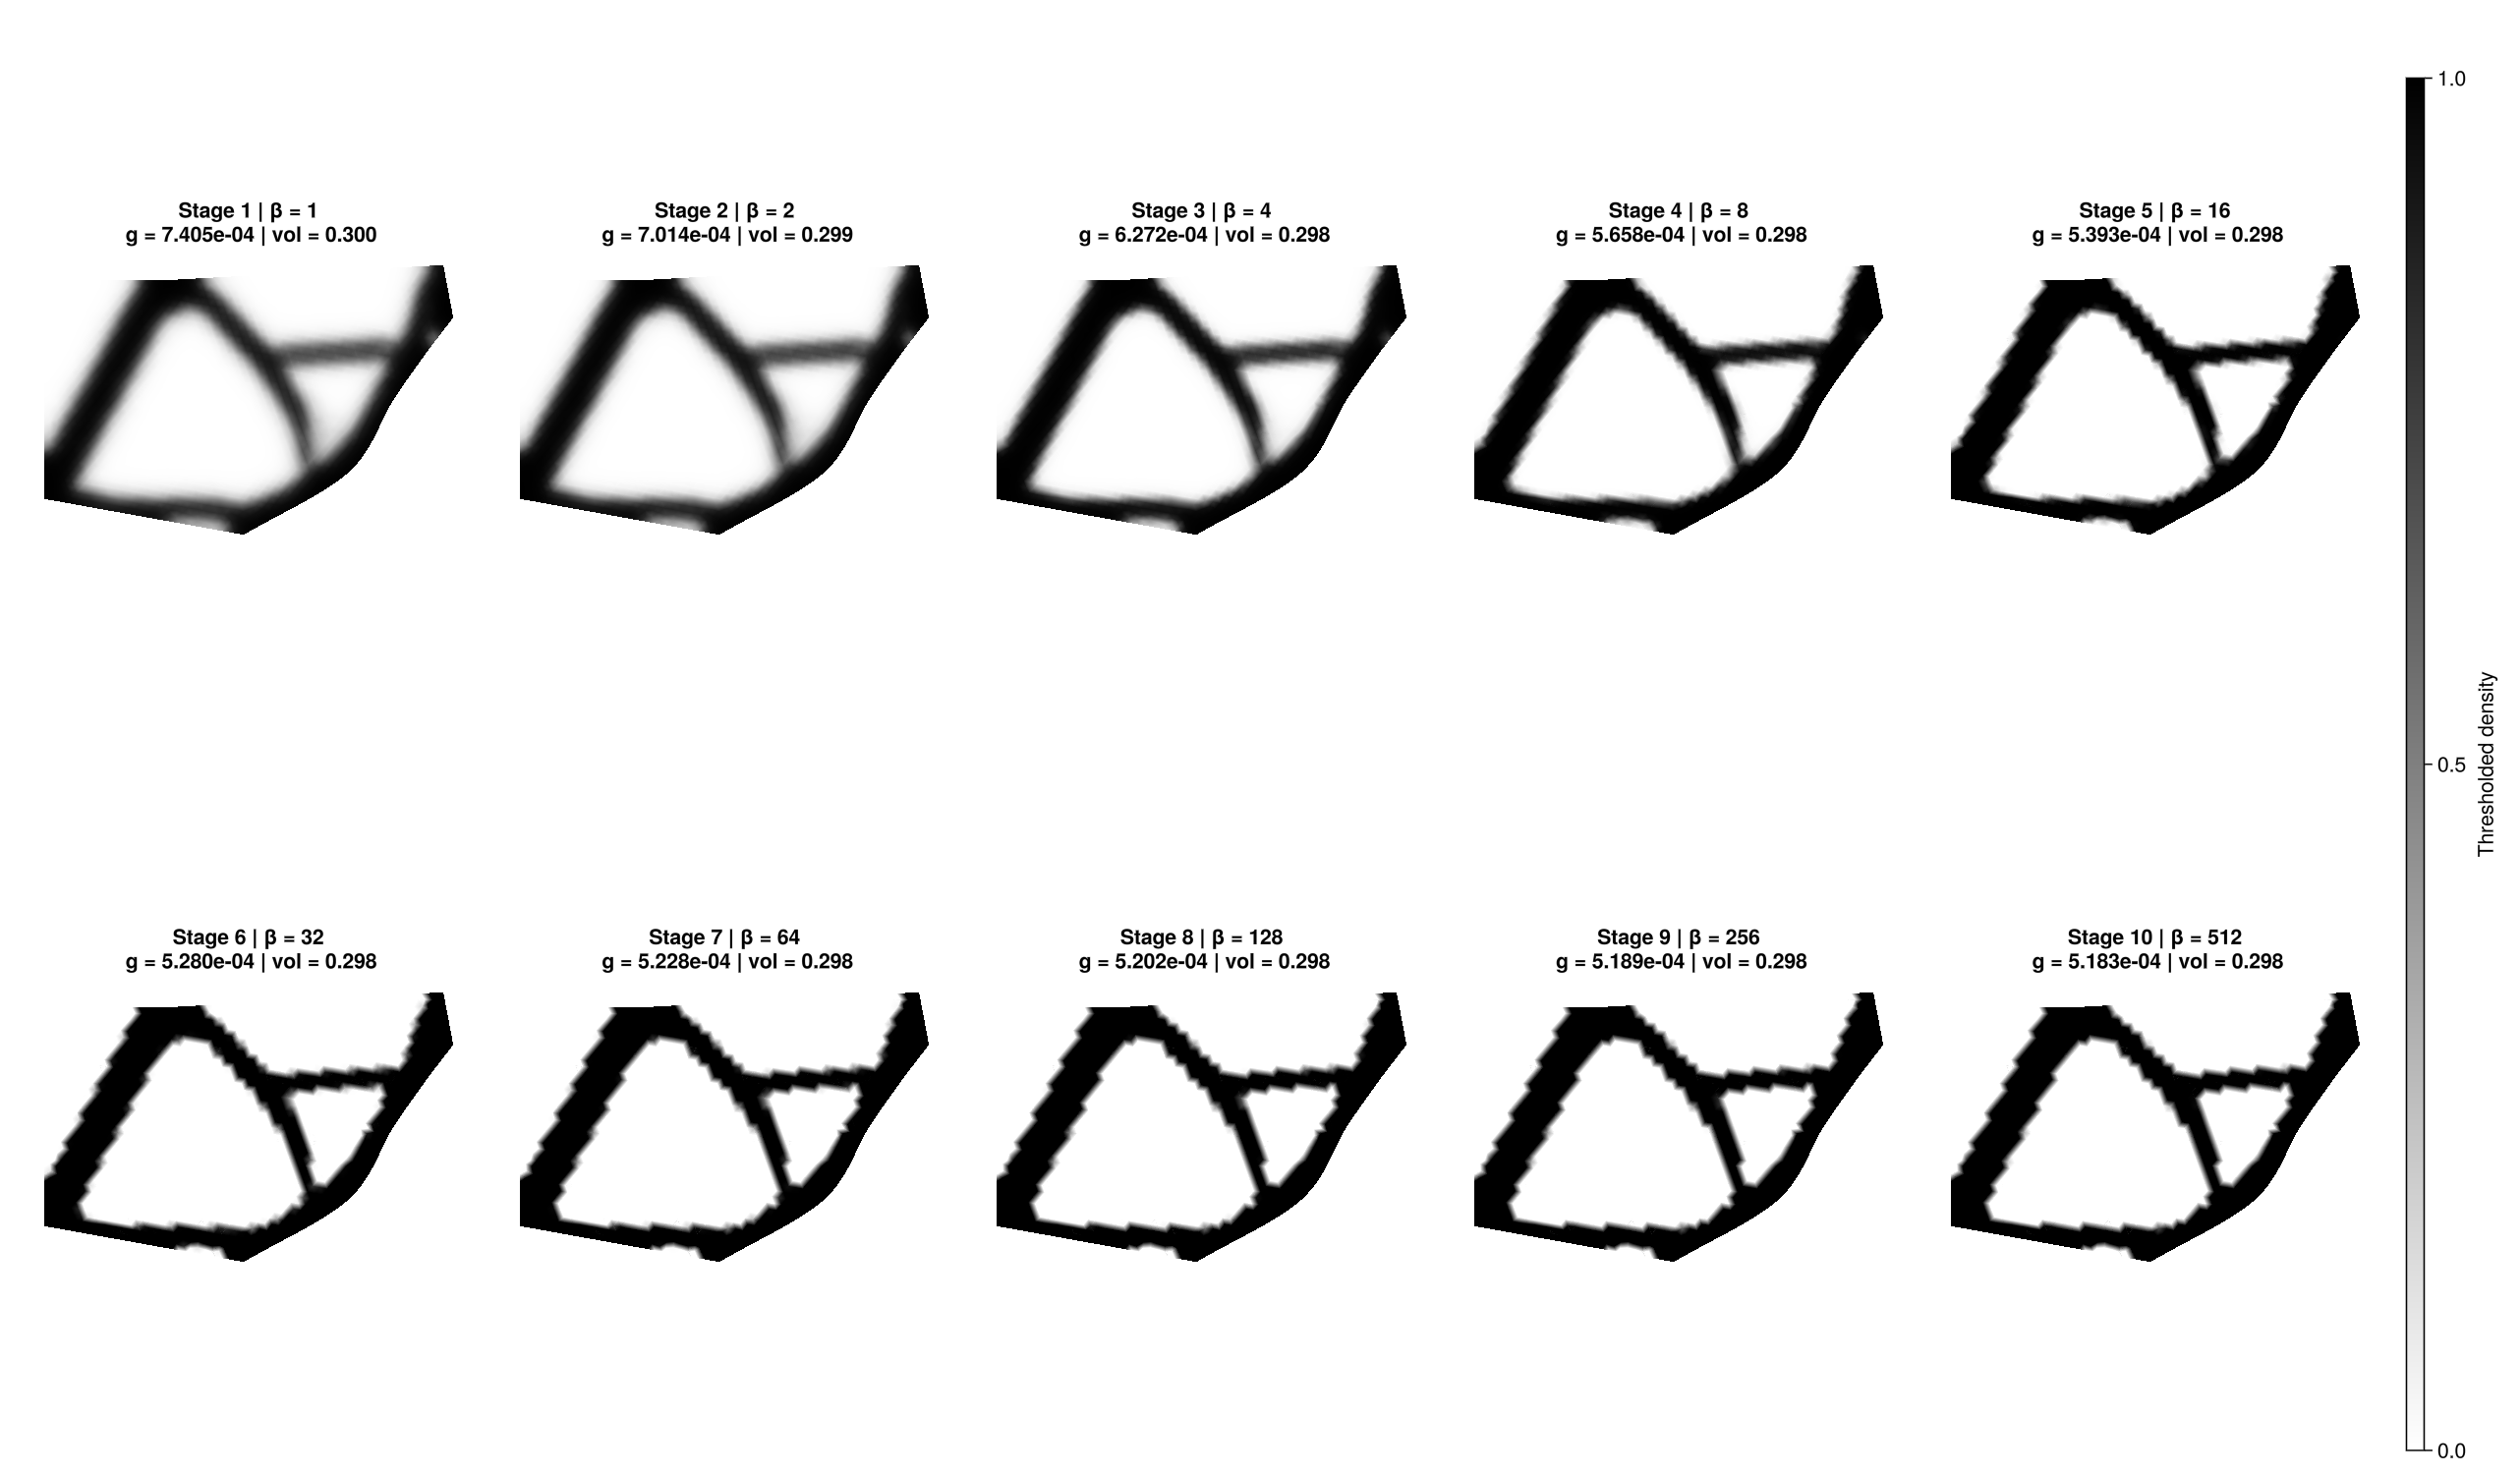

In [34]:
# Plot 1 figure with all checkpoints (THIS IS 2D)
fig = plot_checkpoint_shapes(
    "bike_mma";
    r = r,
    η = 0.5,                  # or whatever η you used in that run
    fem_params = fem_params,
    ncols = 5,
    outfile = "bike_mma/bike_mma_checkpoints.png"
)

In [38]:
# Cut out low-density regions for clearer visualization of the "visible" structure at each stage
function checkpoint_visible_field(p_vec, β_stage; r, η, fem_params, cutoff = 0.05)
    pf_vec = pf_p0(p_vec; r = r, fem_params = fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β = β_stage, η = η)) ∘ pfh

    # Hide low-density regions
    pvis = (ρ -> ρ > cutoff ? ρ : NaN) ∘ pth

    return pth, pvis
end

checkpoint_visible_field (generic function with 1 method)

In [45]:
# Static 3D plot with low-density cutoff for clearer visualization of the evolving structure
function plot_checkpoint_shapes_3d_transparent(save_prefix; r, η, fem_params,
                                               ncols = 3,
                                               outfile = nothing,
                                               azimuth = 0.9,
                                               elevation = 0.35,
                                               cutoff = 0.05)

    meta = get_checkpoint_metadata(save_prefix)
    hist = load_stage_history(save_prefix)

    nplots = length(meta)
    nrows = cld(nplots, ncols)

    fig = Figure(size = (700 * ncols, 600 * nrows))
    rowgap!(fig.layout, 5)
    colgap!(fig.layout, 5)
    last_plt = nothing

    for (k, info) in enumerate(meta)
        row = cld(k, ncols)
        col = k - (row - 1) * ncols

        p_vec = deserialize(info.path)
        pth, pvis = checkpoint_visible_field(
            p_vec, info.β;
            r = r, η = η, fem_params = fem_params, cutoff = cutoff
        )

        ax = Axis3(
            fig[row, col];
            aspect = :data,
            azimuth = azimuth,
            elevation = elevation,
            perspectiveness = 0.2,
            titlegap = 2,
        )

        last_plt = plot!(
            ax,
            fem_params.Ω,
            pvis;
            colormap = :binary,
            colorrange = (0.0, 1.0),
            nan_color = RGBAf(0, 0, 0, 0)
        )

        hidedecorations!(ax)
        hidespines!(ax)

        ax.xspinesvisible = false
        ax.yspinesvisible = false
        ax.zspinesvisible = false

        if hist !== nothing && haskey(hist, info.stage)
            g_stage = hist[info.stage].g
            vol_stage = hist[info.stage].vol
            ax.title = @sprintf(
                "Stage %d | β = %.0f\n g = %.3e | vol = %.3f",
                info.stage, info.β, g_stage, vol_stage
            )
        else
            ax.title = @sprintf("Stage %d | β = %.0f", info.stage, info.β)
        end
    end

    if last_plt !== nothing
        Colorbar(fig[:, ncols + 1], last_plt, label = "Thresholded density")
    end

    if outfile !== nothing
        save(outfile, fig)
    end

    return fig
end

plot_checkpoint_shapes_3d_transparent (generic function with 1 method)

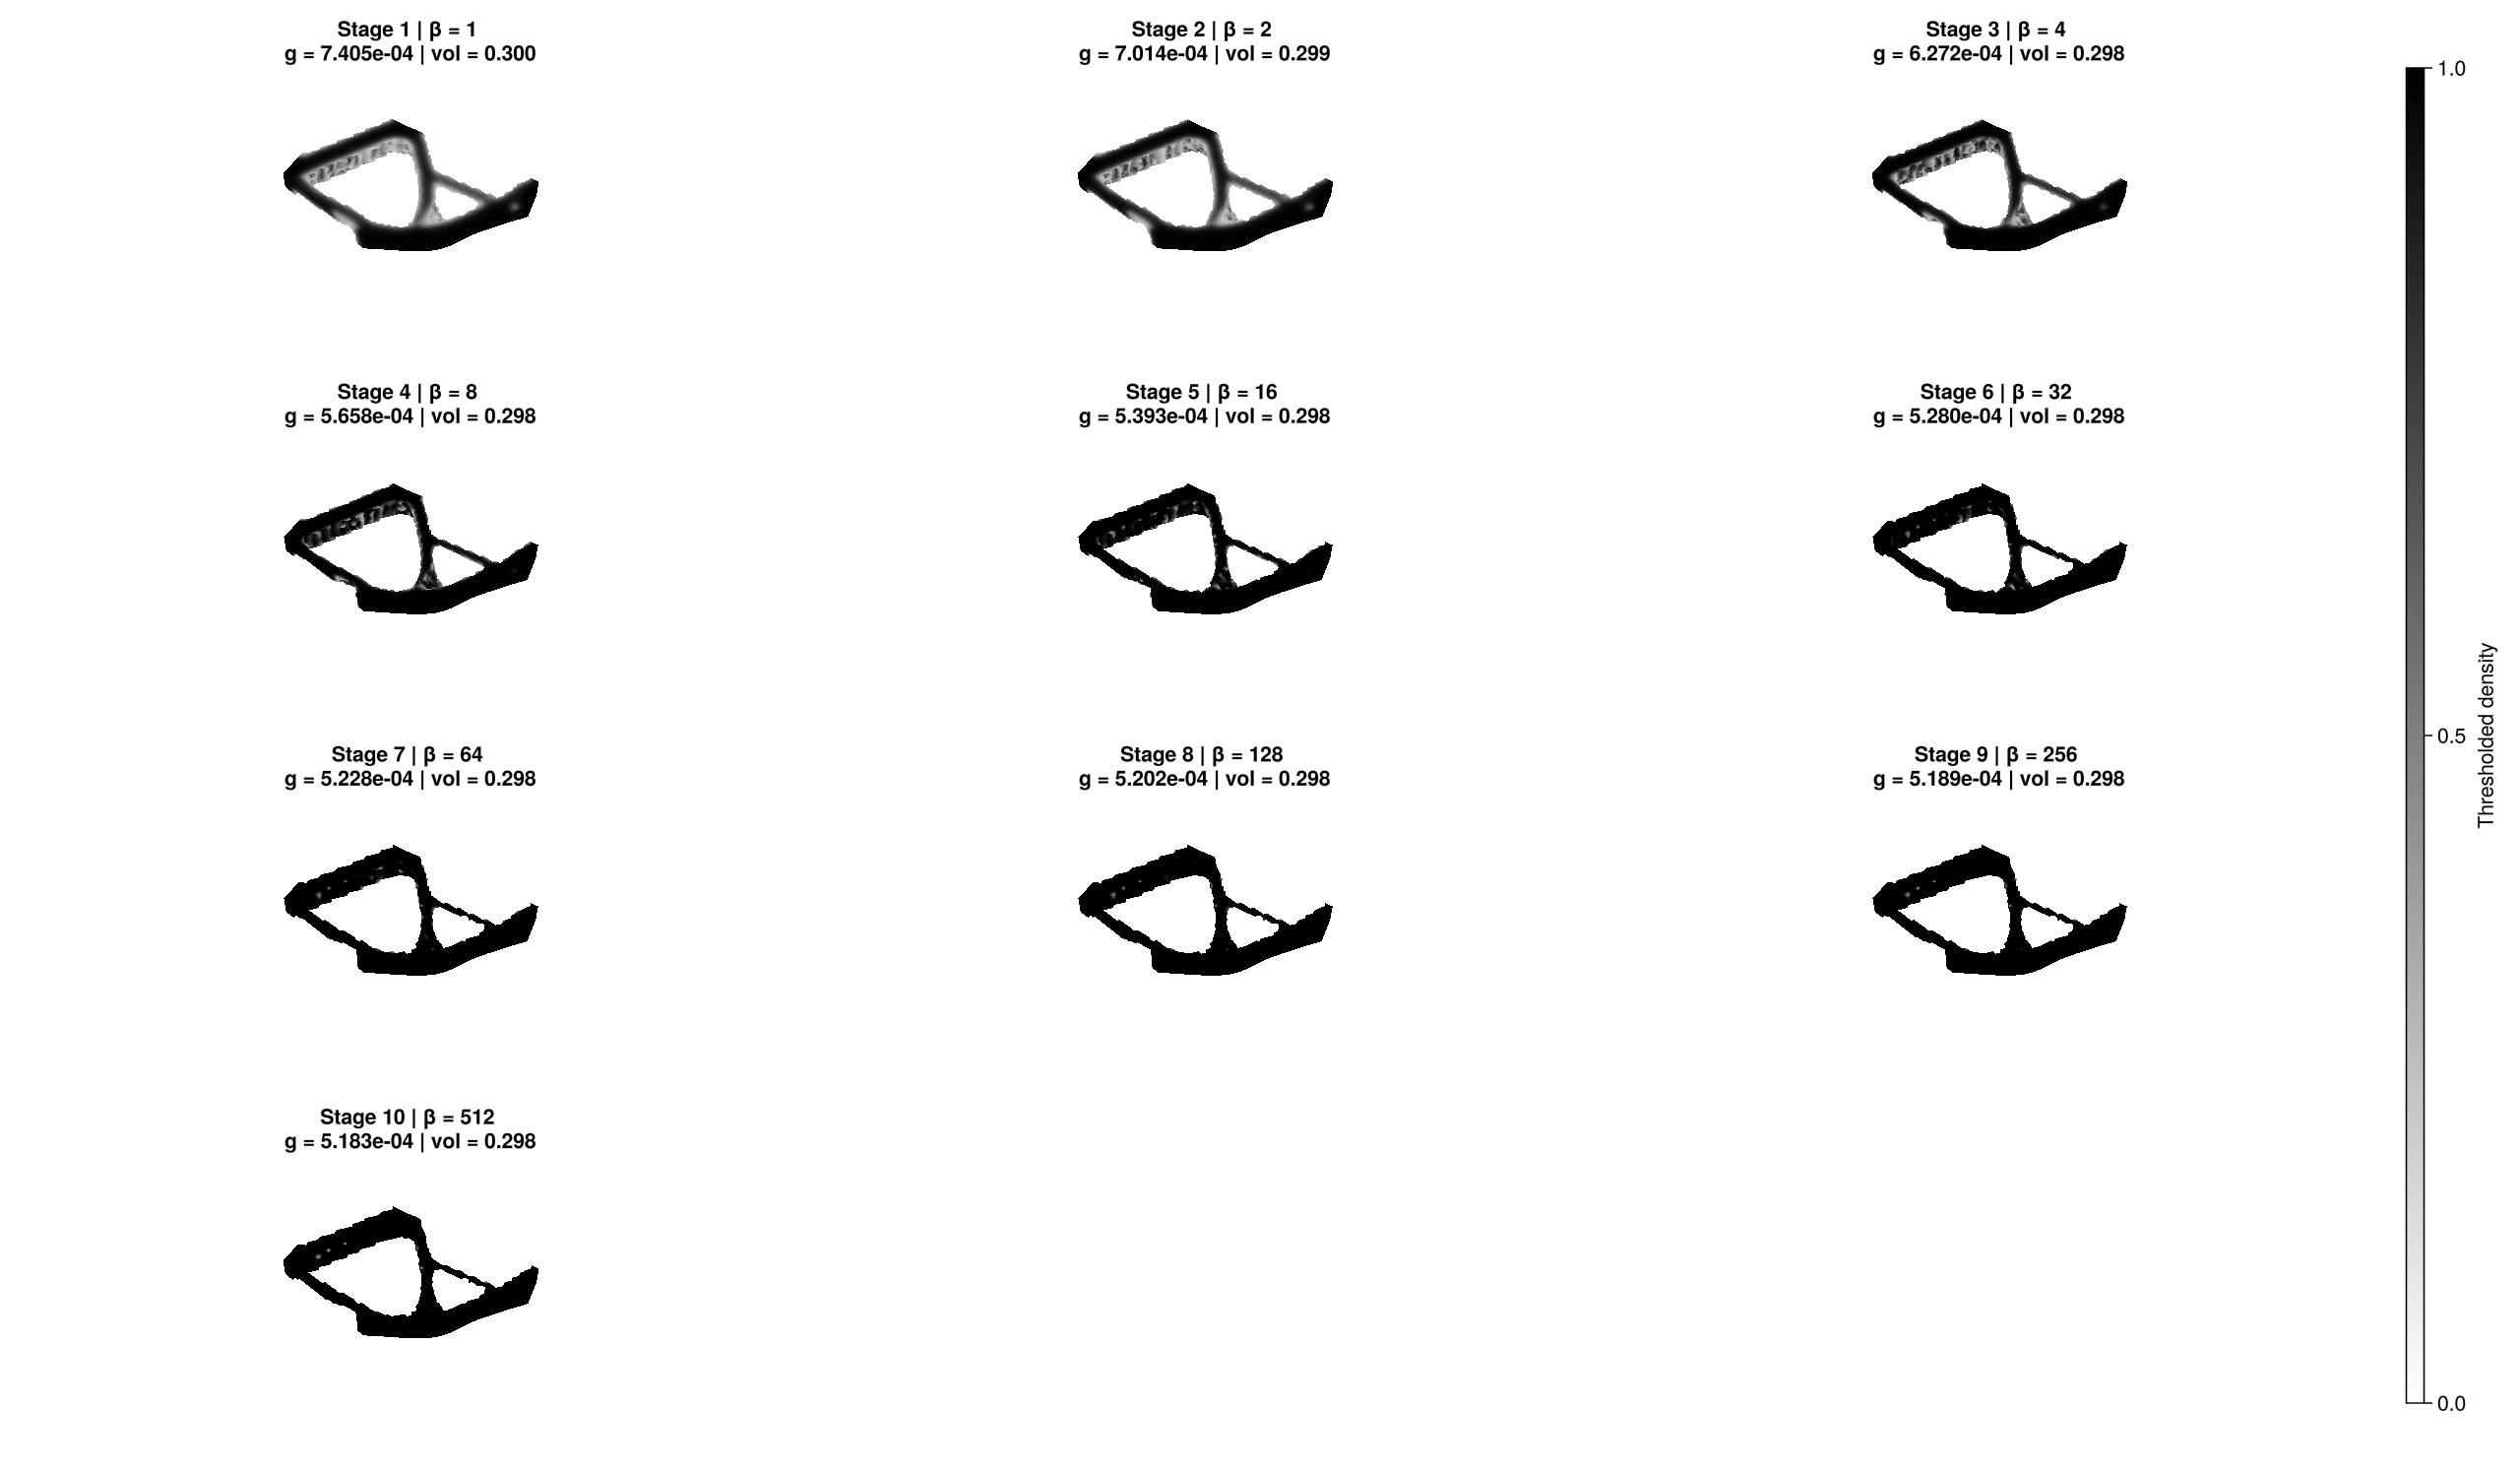

In [53]:
fig = plot_checkpoint_shapes_3d_transparent(
    "bike_mma";
    r = r,
    η = 0.5,
    fem_params = fem_params,
    ncols = 3,
    outfile = "bike_mma/checkpoints_3d_transparent.png",
    azimuth = -1,
    elevation = 0.9,
    cutoff = 0.2
)